In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.compose import make_column_selector as selector #Para seleccionar de forma automática las variables numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder #Para codificar las variables categóricas usando dummies
from sklearn.preprocessing import StandardScaler #Para normalizar las variables numéricas
from sklearn.compose import ColumnTransformer #Modifica las columnas usando los preprocesadores
from sklearn.pipeline import make_pipeline #Planifica una secuencia de procesos
from sklearn import set_config #Para mostrar graficamente el pipeline
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

In [3]:
# Cargar el archivo
df = pd.read_csv('violencia_unite_data.csv')

# Convertir 'CONDUCENTE' a binario: 1.0 -> 1, 2.0 o 9.0 -> 0
df['CONDUCENTE'] = df['CONDUCENTE'].replace({2.0: 0, 9.0: 0})

# Eliminar filas con valores nulos en la variable objetivo
df = df.dropna(subset=['CONDUCENTE'])

In [4]:
# Variable objetivo
y = df['CONDUCENTE']

# Selección de características
X = df[[
    'REP_DEP', 'REP_MUNI', 'VIC_SEXO', 'VIC_EDAD',
    'AGR_SEXO', 'AGR_EDAD', 'VIC_GRUPET', 'AGR_GRUPET',
    'VIC_NACIONAL', 'AGR_NACIONAL', 'VIC_OCUP', 'AGR_OCUP',
    'HEC_DEP', 'HEC_MUNI', 'HEC_AREA'
]]
# Separar columnas categóricas y numéricas
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Crear transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'  # Deja pasar columnas numéricas tal cual
)

In [5]:
from sklearn.preprocessing import StandardScaler

# Transformador para características numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)  # Normalización de columnas numéricas
    ],
    remainder='passthrough'
)

In [6]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18128 entries, 1459 to 29490
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   REP_DEP       18128 non-null  object
 1   REP_MUNI      18128 non-null  object
 2   VIC_SEXO      18128 non-null  object
 3   VIC_EDAD      18128 non-null  int64 
 4   AGR_SEXO      18128 non-null  object
 5   AGR_EDAD      18128 non-null  int64 
 6   VIC_GRUPET    18128 non-null  object
 7   AGR_GRUPET    18128 non-null  object
 8   VIC_NACIONAL  18128 non-null  object
 9   AGR_NACIONAL  18128 non-null  object
 10  VIC_OCUP      6581 non-null   object
 11  AGR_OCUP      16106 non-null  object
 12  HEC_DEP       18128 non-null  object
 13  HEC_MUNI      18128 non-null  object
 14  HEC_AREA      18128 non-null  object
dtypes: int64(2), object(13)
memory usage: 2.2+ MB


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

# Crear un pipeline con el preprocesamiento y el clasificador
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000, random_state=42))
])

# Entrenar el modelo
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA']),
                                                 ('num', StandardScaler(),
                                                  ['VIC_EDAD', 'AGR_EDAD'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=1000,
                               random_state=42))])

In [9]:
y_pred = model.predict(X_test)
y_pred

array([1., 1., 0., ..., 1., 1., 0.])

Matriz de confusión
 [[ 606 1079]
 [ 498 2350]]
Accuracy:  0.6521067725568056
Precision:  0.6521067725568056
recall:  0.6521067725568056


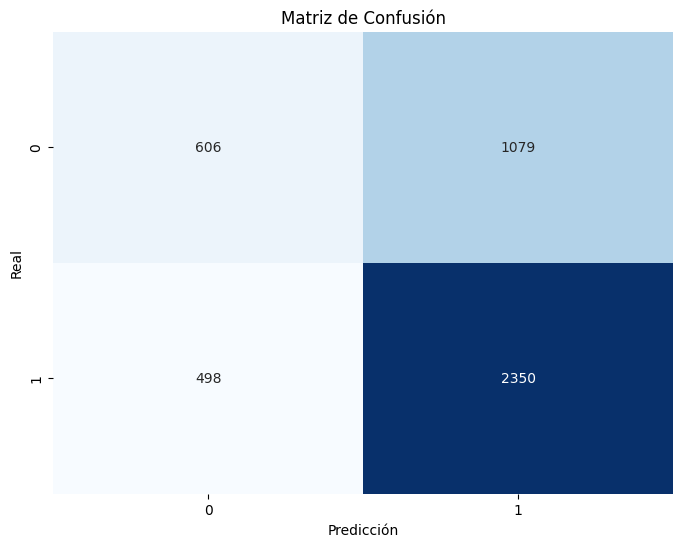

In [ ]:
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)
print('f1score: ',f1)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [13]:
# Crear un pipeline con el preprocesamiento y el clasificador
model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, ), max_iter=1000, random_state=42, learning_rate='adaptive'))
])

# Entrenar el modelo
model2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA']),
                                                 ('num', StandardScaler(),
                                                  ['VIC_EDAD', 'AGR_EDAD'])])),
                ('classifier',
                 MLPClassifier(learning_rate='adaptive', max_iter=1000,
                               random_state=42))])

Matriz de confusión
 [[ 806  879]
 [ 738 2110]]
Accuracy:  0.6432825943084051
Precision:  0.6432825943084051
recall:  0.6432825943084051


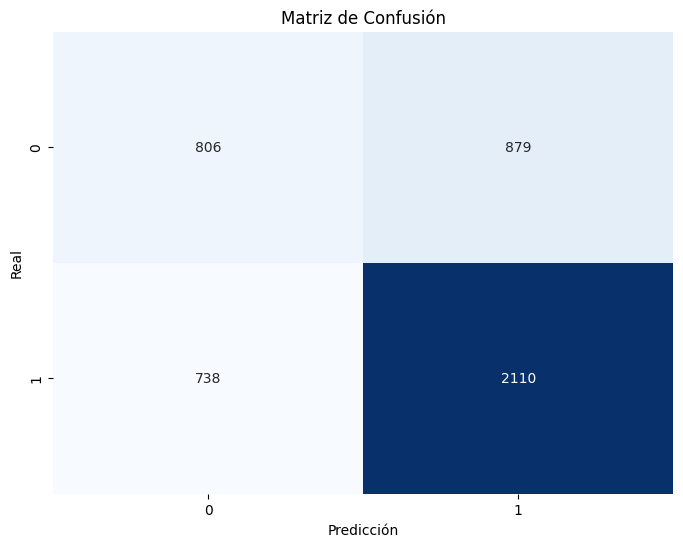

In [14]:
y_pred = model2.predict(X_test)
y_pred
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

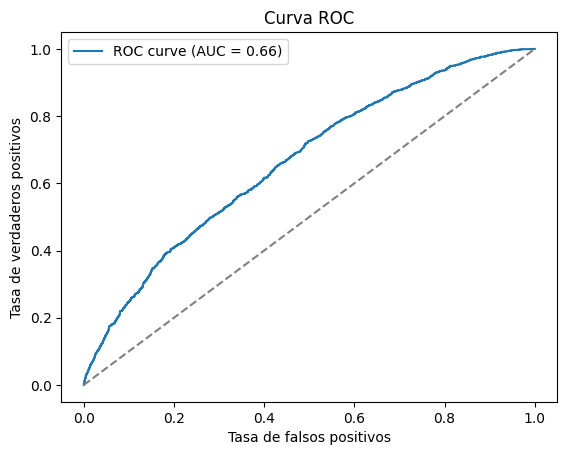

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener probabilidades (no predicciones duras)
y_scores = model2.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()


In [19]:
# Crear un pipeline con el preprocesamiento y el clasificador
model3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(50), max_iter=800, random_state=42, learning_rate='constant', alpha=0.1))
])

# Entrenar el modelo
model3.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['REP_DEP', 'REP_MUNI',
                                                   'VIC_SEXO', 'AGR_SEXO',
                                                   'VIC_GRUPET', 'AGR_GRUPET',
                                                   'VIC_NACIONAL',
                                                   'AGR_NACIONAL', 'VIC_OCUP',
                                                   'AGR_OCUP', 'HEC_DEP',
                                                   'HEC_MUNI', 'HEC_AREA']),
                                                 ('num', StandardScaler(),
                                                  ['VIC_EDAD', 'AGR_EDAD'])])),
                ('classifier',
                 MLPClassifier(alpha=0.1, hidden_layer_sizes=50, max_iter=800,
                               random_state=42))])

Matriz de confusión
 [[ 675 1010]
 [ 475 2373]]
Accuracy:  0.6724023825281271
Precision:  0.6724023825281271
recall:  0.6724023825281271


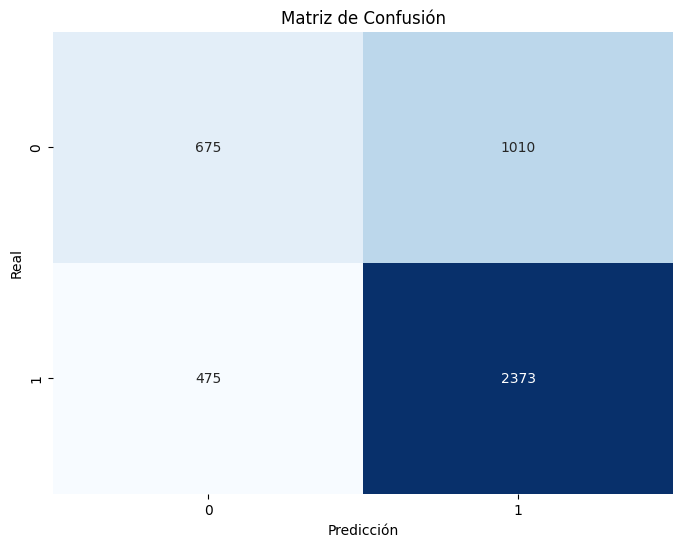

In [20]:
y_pred = model3.predict(X_test)
y_pred
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=True, yticklabels=True)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

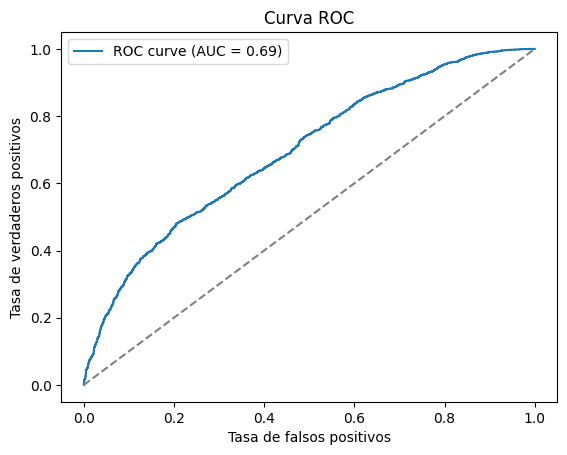

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener probabilidades (no predicciones duras)
y_scores = model3.predict_proba(X_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()
